In [1]:
# ============================================
# Data Cleaning & Preprocessing
# Vessel Arrival Delay Prediction
# ============================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

plt.rcParams["figure.figsize"] = (10, 6)
sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("../data/raw/vessel_arrival_delay.csv")

print(df.shape)

df.head()

(15100, 20)


,Voyage_ID,Carrier,Vessel_Name,Vessel_Type,Origin_Port,Destination_Port,Distance_NM,Scheduled_Transit_Days,Departure_Delay_Hours,Average_Speed_Knots,Vessel_Age,Cargo_Load_Percentage,Port_Congestion_Index,Weather_Severity,Fuel_Price_USD,Historical_Route_Delay,Season,Customs_Clearance_Risk,Actual_Delay_Hours,Late_Arrival
0,V14846,COSCO,Mary Voyager,Bulk Carrier,Hamburg,Los Angeles,4659,16.1,1.7,14.4,19,88.6,45.7,5.2,805.55,1.1,Spring,Medium,16.6,1
1,V14121,Yang Ming,David Voyager,LNG Carrier,Los Angeles,Antwerp,5571,13.7,8.6,13.9,10,55.9,47.9,6.4,539.09,7.9,Autumn,Low,24.4,1
2,V14861,COSCO,Heather Voyager,Bulk Carrier,Singapore,Mumbai,3422,8.9,0.3,12.3,22,95.3,0.3,9.2,650.76,12.6,Spring,Low,26.9,1
3,V00885,ONE,Rachel Voyager,Oil Tanker,Colombo,Mumbai,1300,4.0,NaN,17.7,25,96.1,NaN,NaN,NaN,NaN,Summer,High,25.2,1
4,V00412,CMA CGM,Karen Voyager,Container,Busan,Shanghai,11140,42.2,18.9,15.6,15,64.0,41.3,6.2,669.18,3.2,Autumn,High,29.9,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15100 entries, 0 to 15099
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Voyage_ID               15100 non-null  str    
 1   Carrier                 15100 non-null  str    
 2   Vessel_Name             15100 non-null  str    
 3   Vessel_Type             15100 non-null  str    
 4   Origin_Port             15100 non-null  str    
 5   Destination_Port        15100 non-null  str    
 6   Distance_NM             15100 non-null  int64  
 7   Scheduled_Transit_Days  15100 non-null  float64
 8   Departure_Delay_Hours   14550 non-null  float64
 9   Average_Speed_Knots     15100 non-null  float64
 10  Vessel_Age              15100 non-null  int64  
 11  Cargo_Load_Percentage   15100 non-null  float64
 12  Port_Congestion_Index   14550 non-null  float64
 13  Weather_Severity        14550 non-null  float64
 14  Fuel_Price_USD          14550 non-null  float64
 

In [4]:
df.describe()

,Distance_NM,Scheduled_Transit_Days,Departure_Delay_Hours,Average_Speed_Knots,Vessel_Age,Cargo_Load_Percentage,Port_Congestion_Index,Weather_Severity,Fuel_Price_USD,Historical_Route_Delay,Actual_Delay_Hours,Late_Arrival
count,15100.000000,15100.000000,14550.000000,15100.000000,15100.000000,15100.000000,14550.000000,14550.000000,14550.000000,14550.000000,15100.000000,15100.000000
mean,6305.556490,18.486450,6.249849,18.000146,15.472781,69.824437,50.018247,4.977141,650.725260,8.259299,21.783199,0.894106
std,3335.876651,10.378833,4.527758,3.482798,8.617855,17.307196,28.957550,2.900027,116.092216,5.526371,12.282576,0.307712
min,500.000000,1.100000,0.000000,12.000000,1.000000,40.000000,0.000000,0.000000,450.050000,0.000000,0.100000,0.000000
25%,3403.000000,9.700000,2.500000,15.000000,8.000000,54.800000,24.700000,2.500000,549.632500,3.900000,16.000000,1.000000
50%,6332.500000,18.000000,5.900000,18.000000,15.000000,69.900000,50.150000,4.900000,651.745000,8.000000,21.200000,1.000000
75%,9223.000000,26.300000,9.400000,21.000000,23.000000,84.700000,75.200000,7.500000,751.315000,12.100000,26.500000,1.000000
max,11999.000000,47.700000,28.400000,24.000000,30.000000,100.000000,100.000000,10.000000,849.870000,30.100000,359.100000,1.000000


In [5]:
df.describe(include="object")

C:\Users\rufiy\AppData\Local\Temp\ipykernel_10800\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Voyage_ID,Carrier,Vessel_Name,Vessel_Type,Origin_Port,Destination_Port,Season,Customs_Clearance_Risk
count,15100,15100,15100,15100,15100,15100,15100,15100
unique,15000,11,676,4,10,10,4,3
top,V02885,MSC,Michael Voyager,LNG Carrier,Rotterdam,Mumbai,Spring,High
freq,2,1974,313,3801,1561,1570,3823,5099


In [6]:
duplicates = df.duplicated().sum()

print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 99


In [7]:
df = df.drop_duplicates()

In [8]:
print(df.shape)
print(df.duplicated().sum())

(15001, 20)
0


In [9]:
missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

Departure_Delay_Hours     451
Port_Congestion_Index     451
Weather_Severity          451
Fuel_Price_USD            451
Historical_Route_Delay    451
dtype: int64

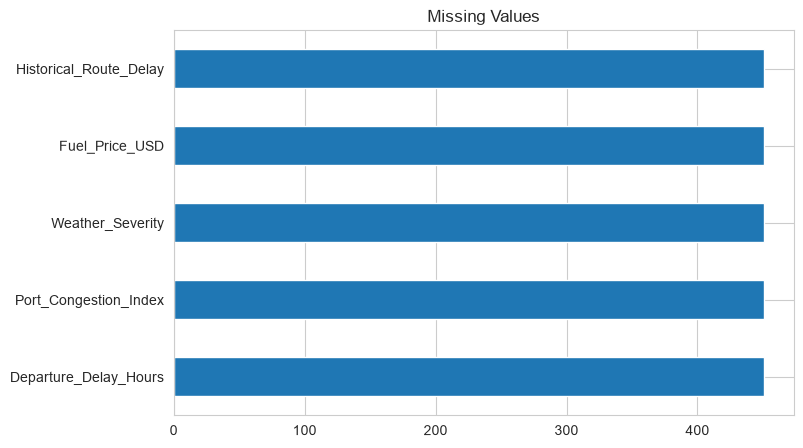

In [10]:
plt.figure(figsize=(8,5))

missing.sort_values().plot(kind="barh")

plt.title("Missing Values")

plt.show()

In [11]:
numeric_columns = [
    "Departure_Delay_Hours",
    "Weather_Severity",
    "Port_Congestion_Index",
    "Fuel_Price_USD",
    "Historical_Route_Delay"
]

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

In [12]:
df.isnull().sum()

Voyage_ID                 0
Carrier                   0
Vessel_Name               0
Vessel_Type               0
Origin_Port               0
Destination_Port          0
Distance_NM               0
Scheduled_Transit_Days    0
Departure_Delay_Hours     0
Average_Speed_Knots       0
Vessel_Age                0
Cargo_Load_Percentage     0
Port_Congestion_Index     0
Weather_Severity          0
Fuel_Price_USD            0
Historical_Route_Delay    0
Season                    0
Customs_Clearance_Risk    0
Actual_Delay_Hours        0
Late_Arrival              0
dtype: int64

In [13]:
print("Unique Carrier Values:\n")
print(df["Carrier"].unique())

print("\nCarrier Counts:\n")
print(df["Carrier"].value_counts())

Unique Carrier Values:

<StringArray>
[      'COSCO',   'Yang Ming',         'ONE',     'CMA CGM',   'Evergreen',
         'MSC',      'Maersk', 'Hapag-Lloyd',        'MSC ',      'maersk',
     'CMA-CGM']
Length: 11, dtype: str

Carrier Counts:

Carrier
MSC            1964
COSCO          1895
Maersk         1877
Yang Ming      1854
CMA CGM        1853
ONE            1841
Hapag-Lloyd    1824
Evergreen      1803
maersk           40
MSC              30
CMA-CGM          20
Name: count, dtype: int64


In [14]:
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    df[column] = df[column].str.strip()

C:\Users\rufiy\AppData\Local\Temp\ipykernel_10800\1055053267.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


In [15]:
carrier_mapping = {
    "maersk": "Maersk",
    "MSC": "MSC",
    "CMA-CGM": "CMA CGM"
}

df["Carrier"] = df["Carrier"].replace(carrier_mapping)

In [16]:
print(df["Carrier"].value_counts())

Carrier
MSC            1994
Maersk         1917
COSCO          1895
CMA CGM        1873
Yang Ming      1854
ONE            1841
Hapag-Lloyd    1824
Evergreen      1803
Name: count, dtype: int64


In [17]:
for column in categorical_columns:
    print("=" * 50)
    print(column)
    print(df[column].unique())

Voyage_ID
<StringArray>
['V14846', 'V14121', 'V14861', 'V00885', 'V00412', 'V06483', 'V01359',
 'V07741', 'V00488', 'V01108',
 ...
 'V00467', 'V06266', 'V05735', 'V11285', 'V11965', 'V05192', 'V13419',
 'V05391', 'V00861', 'V07271']
Length: 15000, dtype: str
Carrier
<StringArray>
[      'COSCO',   'Yang Ming',         'ONE',     'CMA CGM',   'Evergreen',
         'MSC',      'Maersk', 'Hapag-Lloyd']
Length: 8, dtype: str
Vessel_Name
<StringArray>
[   'Mary Voyager',   'David Voyager', 'Heather Voyager',  'Rachel Voyager',
   'Karen Voyager', 'Shirley Voyager',  'Morgan Voyager',   'Julie Voyager',
   'Tanya Voyager',    'Tina Voyager',
 ...
   'Norma Voyager',   'Tasha Voyager',  'Ronnie Voyager',  'Darryl Voyager',
   'Marco Voyager',  'Marisa Voyager',  'Claire Voyager',    'Karl Voyager',
  'Alfred Voyager',   'Wyatt Voyager']
Length: 676, dtype: str
Vessel_Type
<StringArray>
['Bulk Carrier', 'LNG Carrier', 'Oil Tanker', 'Container']
Length: 4, dtype: str
Origin_Port
<StringArray>
[

In [18]:
df.dtypes

Voyage_ID                     str
Carrier                       str
Vessel_Name                   str
Vessel_Type                   str
Origin_Port                   str
Destination_Port              str
Distance_NM                 int64
Scheduled_Transit_Days    float64
Departure_Delay_Hours     float64
Average_Speed_Knots       float64
Vessel_Age                  int64
Cargo_Load_Percentage     float64
Port_Congestion_Index     float64
Weather_Severity          float64
Fuel_Price_USD            float64
Historical_Route_Delay    float64
Season                        str
Customs_Clearance_Risk        str
Actual_Delay_Hours        float64
Late_Arrival                int64
dtype: object

In [19]:
category_columns = [
    "Carrier",
    "Vessel_Type",
    "Origin_Port",
    "Destination_Port",
    "Season",
    "Customs_Clearance_Risk",
    "Late_Arrival"
]

for column in category_columns:
    df[column] = df[column].astype("category")

In [20]:
df.info()

<class 'pandas.DataFrame'>
Index: 15001 entries, 0 to 15099
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   Voyage_ID               15001 non-null  str     
 1   Carrier                 15001 non-null  category
 2   Vessel_Name             15001 non-null  str     
 3   Vessel_Type             15001 non-null  category
 4   Origin_Port             15001 non-null  category
 5   Destination_Port        15001 non-null  category
 6   Distance_NM             15001 non-null  int64   
 7   Scheduled_Transit_Days  15001 non-null  float64 
 8   Departure_Delay_Hours   15001 non-null  float64 
 9   Average_Speed_Knots     15001 non-null  float64 
 10  Vessel_Age              15001 non-null  int64   
 11  Cargo_Load_Percentage   15001 non-null  float64 
 12  Port_Congestion_Index   15001 non-null  float64 
 13  Weather_Severity        15001 non-null  float64 
 14  Fuel_Price_USD          15001 non-null

In [21]:
print("Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nUnique Carriers:")
print(df["Carrier"].unique())

Shape: (15001, 20)

Missing Values:
0

Duplicate Rows:
0

Unique Carriers:
['COSCO', 'Yang Ming', 'ONE', 'CMA CGM', 'Evergreen', 'MSC', 'Maersk', 'Hapag-Lloyd']
Categories (8, str): ['CMA CGM', 'COSCO', 'Evergreen', 'Hapag-Lloyd', 'MSC', 'Maersk', 'ONE', 'Yang Ming']


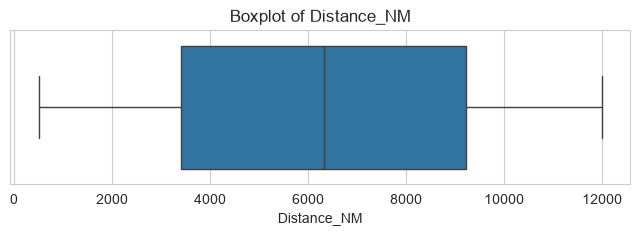

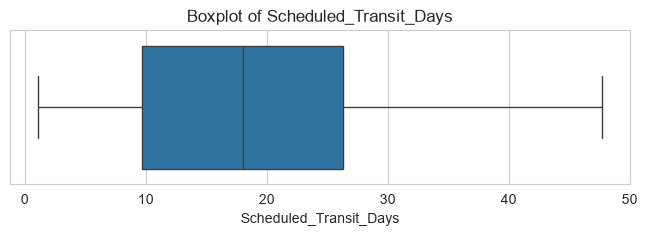

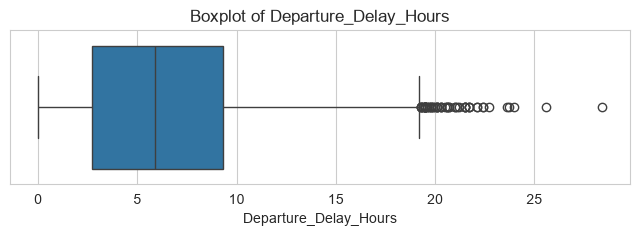

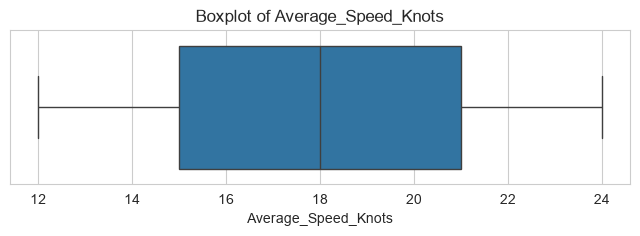

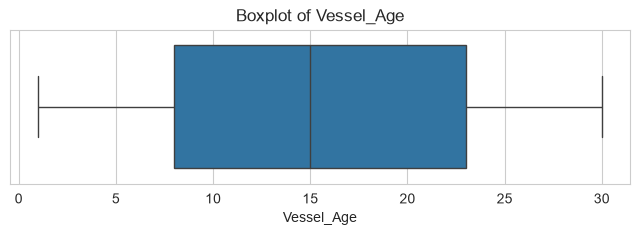

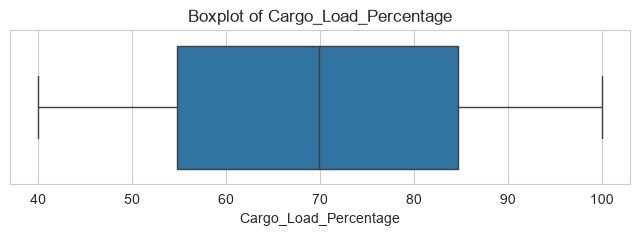

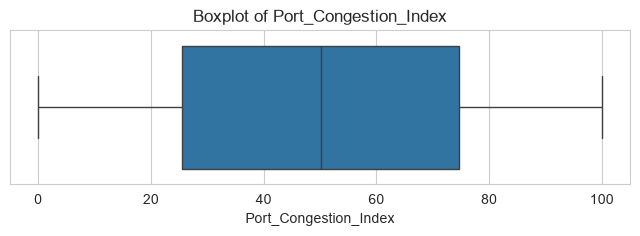

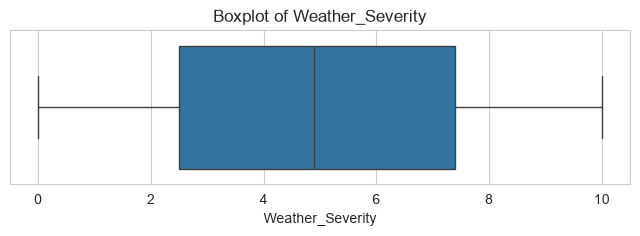

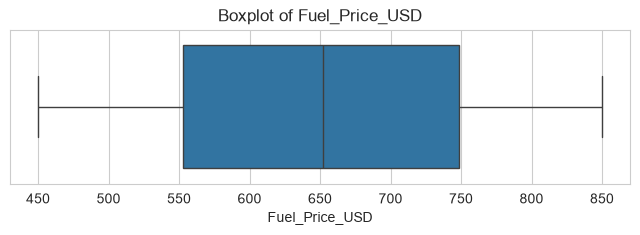

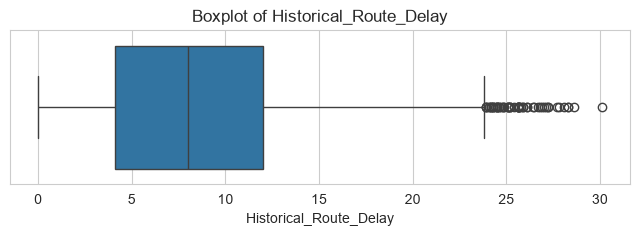

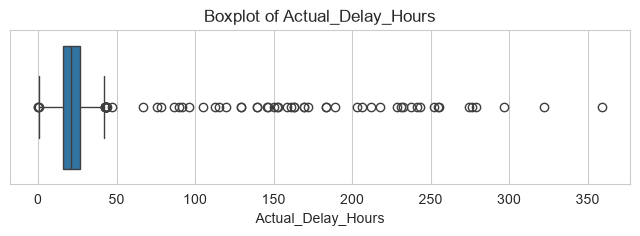

In [22]:
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns

for column in numeric_columns:
    plt.figure(figsize=(8, 2))

    sns.boxplot(x=df[column])

    plt.title(f"Boxplot of {column}")

    plt.show()

In [23]:
def detect_outliers_iqr(dataframe, column):

    Q1 = dataframe[column].quantile(0.25)

    Q3 = dataframe[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR

    upper_bound = Q3 + 1.5 * IQR

    outliers = dataframe[
        (dataframe[column] < lower_bound) |
        (dataframe[column] > upper_bound)
    ]

    return outliers

In [24]:
for column in numeric_columns:

    outliers = detect_outliers_iqr(df, column)

    print(f"{column:<30} {len(outliers)}")

Distance_NM                    0
Scheduled_Transit_Days         0
Departure_Delay_Hours          58
Average_Speed_Knots            0
Vessel_Age                     0
Cargo_Load_Percentage          0
Port_Congestion_Index          0
Weather_Severity               0
Fuel_Price_USD                 0
Historical_Route_Delay         58
Actual_Delay_Hours             64


In [25]:
actual_delay_outliers = detect_outliers_iqr(df, "Actual_Delay_Hours")

actual_delay_outliers.head()

,Voyage_ID,Carrier,Vessel_Name,Vessel_Type,Origin_Port,Destination_Port,Distance_NM,Scheduled_Transit_Days,Departure_Delay_Hours,Average_Speed_Knots,Vessel_Age,Cargo_Load_Percentage,Port_Congestion_Index,Weather_Severity,Fuel_Price_USD,Historical_Route_Delay,Season,Customs_Clearance_Risk,Actual_Delay_Hours,Late_Arrival
55,V09210,Hapag-Lloyd,Melody Voyager,Oil Tanker,Shanghai,Antwerp,5926,15.4,0.0,21.9,14,53.6,99.1,7.5,795.38,9.1,Winter,Medium,254.7,1
163,V10131,Maersk,Ryan Voyager,Container,Shanghai,Hamburg,10006,22.9,3.5,16.8,22,41.2,41.4,7.0,684.31,6.7,Autumn,High,183.6,1
201,V14264,Evergreen,Ashley Voyager,Container,Busan,Singapore,671,2.4,12.0,12.2,9,99.9,95.2,9.1,665.29,27.2,Autumn,Low,43.1,1
567,V14130,MSC,Michael Voyager,Bulk Carrier,Los Angeles,Singapore,7681,20.8,10.6,16.3,12,60.8,94.9,8.8,470.02,19.3,Summer,Medium,43.3,1
925,V05067,Hapag-Lloyd,Brooke Voyager,Oil Tanker,Colombo,Hamburg,8491,27.7,14.4,16.5,14,52.5,90.0,9.6,533.45,15.4,Summer,High,43.3,1


In [26]:
def cap_outliers_iqr(dataframe, column):

    Q1 = dataframe[column].quantile(0.25)

    Q3 = dataframe[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR

    upper = Q3 + 1.5 * IQR

    dataframe[column] = dataframe[column].clip(lower, upper)

    return dataframe

In [27]:
columns_to_cap = [
    "Departure_Delay_Hours",
    "Historical_Route_Delay",
    "Actual_Delay_Hours"
]

for column in columns_to_cap:

    df = cap_outliers_iqr(df, column)

In [28]:
for column in columns_to_cap:

    outliers = detect_outliers_iqr(df, column)

    print(f"{column:<30} {len(outliers)}")

Departure_Delay_Hours          0
Historical_Route_Delay         0
Actual_Delay_Hours             0


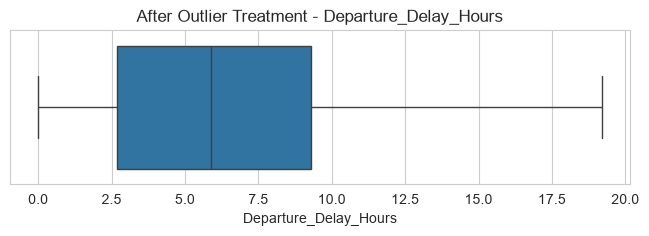

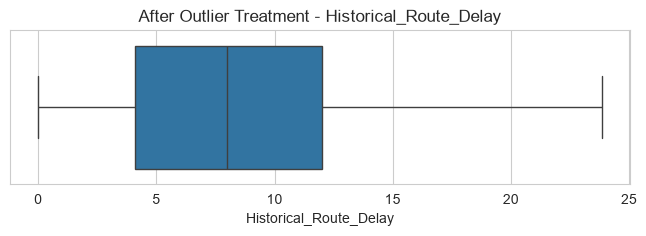

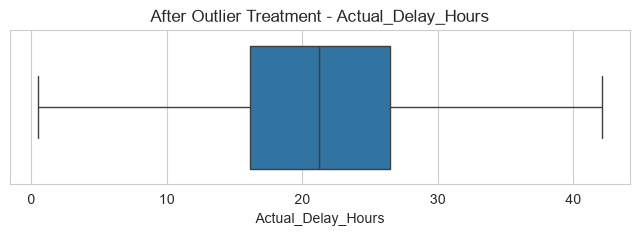

In [29]:
for column in columns_to_cap:

    plt.figure(figsize=(8, 2))

    sns.boxplot(x=df[column])

    plt.title(f"After Outlier Treatment - {column}")

    plt.show()

In [30]:
print("=" * 50)
print("DATASET VALIDATION")
print("=" * 50)

print(f"Shape: {df.shape}")

print(f"\nMissing Values: {df.isnull().sum().sum()}")

print(f"\nDuplicate Rows: {df.duplicated().sum()}")

print("\nData Types:")
print(df.dtypes)

DATASET VALIDATION
Shape: (15001, 20)

Missing Values: 0

Duplicate Rows: 0

Data Types:
Voyage_ID                      str
Carrier                   category
Vessel_Name                    str
Vessel_Type               category
Origin_Port               category
Destination_Port          category
Distance_NM                  int64
Scheduled_Transit_Days     float64
Departure_Delay_Hours      float64
Average_Speed_Knots        float64
Vessel_Age                   int64
Cargo_Load_Percentage      float64
Port_Congestion_Index      float64
Weather_Severity           float64
Fuel_Price_USD             float64
Historical_Route_Delay     float64
Season                    category
Customs_Clearance_Risk    category
Actual_Delay_Hours         float64
Late_Arrival              category
dtype: object


In [33]:
output_path = "../data/processed/vessel_arrival_delay_clean.csv"

df.to_csv(output_path, index=False)

print(f"Clean dataset saved to:\n{output_path}")

Clean dataset saved to:
../data/processed/vessel_arrival_delay_clean.csv
